In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import re # For identifying histogram columns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, make_scorer
import lightgbm as lgb
import xgboost as xgb


TRAIN_FILE = 'aps_failure_training_set.csv'
TEST_FILE = 'aps_failure_test_set.csv'
MISSING_VALUE_MARKER = 'na'

# Costs based on the problem description 
# Cost_1: Cost of incorrectly identifying a component as failed (False Positive)
COST_1 = 10
# Cost_2: Cost of missing a faulty component (False Negative)
COST_2 = 500

print("Libraries imported and constants defined.")

Libraries imported and constants defined.


## Load Data 

In [2]:
def load_data(file_path, missing_marker, skip_rows=20):
    """Loads data from CSV, handling the specified missing value marker."""
    try:
        df = pd.read_csv(file_path, na_values=missing_marker, skiprows=skip_rows)
        print(f"Successfully loaded {file_path}. Shape: {df.shape}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Load the datasets
df_train = load_data(TRAIN_FILE, MISSING_VALUE_MARKER)
df_test = load_data(TEST_FILE, MISSING_VALUE_MARKER)

# Basic check after loading
if df_train is not None:
    print("\nTraining data sample:")
    print(df_train.head())
if df_test is not None:
    print("\nTest data sample:")
    print(df_test.head())

Successfully loaded aps_failure_training_set.csv. Shape: (60000, 171)
Successfully loaded aps_failure_test_set.csv. Shape: (16000, 171)

Training data sample:
  class  aa_000  ab_000        ac_000  ad_000  ae_000  af_000  ag_000  ag_001  \
0   neg   76698     NaN  2.130706e+09   280.0     0.0     0.0     0.0     0.0   
1   neg   33058     NaN  0.000000e+00     NaN     0.0     0.0     0.0     0.0   
2   neg   41040     NaN  2.280000e+02   100.0     0.0     0.0     0.0     0.0   
3   neg      12     0.0  7.000000e+01    66.0     0.0    10.0     0.0     0.0   
4   neg   60874     NaN  1.368000e+03   458.0     0.0     0.0     0.0     0.0   

   ag_002  ...     ee_002    ee_003    ee_004    ee_005    ee_006    ee_007  \
0     0.0  ...  1240520.0  493384.0  721044.0  469792.0  339156.0  157956.0   
1     0.0  ...   421400.0  178064.0  293306.0  245416.0  133654.0   81140.0   
2     0.0  ...   277378.0  159812.0  423992.0  409564.0  320746.0  158022.0   
3     0.0  ...      240.0      46.0   

## Exploratory Data Analysis

In [3]:
# Display basic info (data types, non-null counts)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: float64(169), int64(1), object(1)
memory usage: 78.3+ MB


In [4]:
# Display descriptive statistics for numerical columns
print(df_train.describe())

             aa_000        ab_000        ac_000        ad_000        ae_000  \
count  6.000000e+04  13671.000000  5.666500e+04  4.513900e+04  57500.000000   
mean   5.933650e+04      0.713189  3.560143e+08  1.906206e+05      6.819130   
std    1.454301e+05      3.478962  7.948749e+08  4.040441e+07    161.543373   
min    0.000000e+00      0.000000  0.000000e+00  0.000000e+00      0.000000   
25%    8.340000e+02      0.000000  1.600000e+01  2.400000e+01      0.000000   
50%    3.077600e+04      0.000000  1.520000e+02  1.260000e+02      0.000000   
75%    4.866800e+04      0.000000  9.640000e+02  4.300000e+02      0.000000   
max    2.746564e+06    204.000000  2.130707e+09  8.584298e+09  21050.000000   

             af_000        ag_000        ag_001        ag_002        ag_003  \
count  57500.000000  5.932900e+04  5.932900e+04  5.932900e+04  5.932900e+04   
mean      11.006817  2.216364e+02  9.757223e+02  8.606015e+03  8.859128e+04   
std      209.792592  2.047846e+04  3.420053e+04  1.

In [5]:
# Check initial class distribution ('neg'/'pos')
print(df_train['class'].value_counts())

class
neg    59000
pos     1000
Name: count, dtype: int64


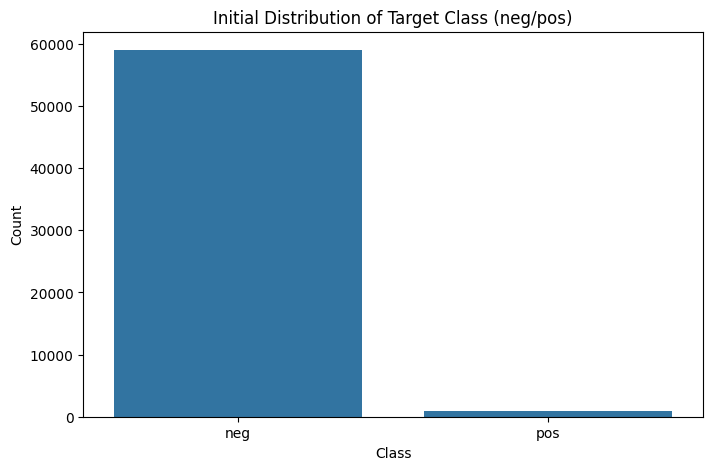

In [6]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df_train, order=df_train['class'].value_counts().index)
plt.title('Initial Distribution of Target Class (neg/pos)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

The EDA indicates a significant class imbalance (a 59:1 ratio). We would need to use techniques like class_weight='balanced' or scale_pos_weight in the models during training and testing.

In [7]:
# Number of missing values 
df_train.isnull().sum()

class         0
aa_000        0
ab_000    46329
ac_000     3335
ad_000    14861
          ...  
ee_007      671
ee_008      671
ee_009      671
ef_000     2724
eg_000     2723
Length: 171, dtype: int64

In [8]:
def preprocess_data(df_train, df_test):
    """Handles target encoding, imputation, and scaling."""
    print("\nStarting preprocessing...")

    if 'class' not in df_train.columns or 'class' not in df_test.columns:
         print("Error: 'class' column missing from DataFrame.")
         return None, None, None, None, None, None, None

    #Separate Target Variable
    X_train = df_train.drop('class', axis=1)
    y_train = df_train['class'].map({'neg': 0, 'pos': 1})
    X_test = df_test.drop('class', axis=1)
    y_test = df_test['class'].map({'neg': 0, 'pos': 1})

    print(f"Training features shape before processing: {X_train.shape}")
    print(f"Test features shape before processing: {X_test.shape}")
    print(f"Missing values before imputation (Train): {X_train.isnull().sum().sum()}")
    print(f"Missing values before imputation (Test): {X_test.isnull().sum().sum()}")

    
    X_train = X_train.apply(pd.to_numeric, errors='coerce')
    X_test = X_test.apply(pd.to_numeric, errors='coerce')

    # Check if conversion created new NaNs 
    print(f"Missing values after initial numeric conversion (Train): {X_train.isnull().sum().sum()}")
    print(f"Missing values after initial numeric conversion (Test): {X_test.isnull().sum().sum()}")

    # Get feature names 
    feature_names = X_train.columns

    # 2. Imputation (using Median)
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test) 

    print(f"Missing values after imputation (Train): {np.isnan(X_train_imputed).sum()}")
    print(f"Missing values after imputation (Test): {np.isnan(X_test_imputed).sum()}")


    # 3. Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imputed)
    X_test_scaled = scaler.transform(X_test_imputed) 

    print("Preprocessing finished.")
    return X_train_scaled, X_test_scaled, y_train, y_test, feature_names, scaler, imputer

In [9]:
# Apply the preprocessing steps
if df_train is not None and df_test is not None:
    processed_data = preprocess_data(df_train, df_test)
    if processed_data:
      X_train_processed, X_test_processed, y_train, y_test, feature_names, scaler, imputer = processed_data
      print("\nData preprocessing applied successfully.")
      print(f"Processed training features shape: {X_train_processed.shape}")
      print(f"Processed test features shape: {X_test_processed.shape}")
    else:
      print("Error during preprocessing. Cannot continue.")
      X_train_processed, X_test_processed, y_train, y_test = None, None, None, None
else:
    print("Data not loaded successfully. Cannot preprocess.")
    X_train_processed, X_test_processed, y_train, y_test = None, None, None, None


Starting preprocessing...
Training features shape before processing: (60000, 170)
Test features shape before processing: (16000, 170)
Missing values before imputation (Train): 850015
Missing values before imputation (Test): 228680
Missing values after initial numeric conversion (Train): 850015
Missing values after initial numeric conversion (Test): 228680
Missing values after imputation (Train): 0
Missing values after imputation (Test): 0
Preprocessing finished.

Data preprocessing applied successfully.
Processed training features shape: (60000, 170)
Processed test features shape: (16000, 170)


In [10]:
##Model Training 

# Calculate scale_pos_weight for LightGBM
neg_count, pos_count = y_train.value_counts()

scale_pos_weight_val = neg_count / pos_count if pos_count > 0 else 1 #
print(f"Calculated scale_pos_weight: {scale_pos_weight_val:.2f}") #


models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, solver='liblinear'), 
    "SVM": SVC(probability=True, random_state=42, class_weight='balanced'), #
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100), 
    "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight_val), 
    "LightGBM": lgb.LGBMClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val) #
}

print("Models defined:")
for name in models.keys():
    print(f"- {name}")


Calculated scale_pos_weight: 59.00
Models defined:
- Logistic Regression
- SVM
- Random Forest
- XGBoost
- LightGBM


In [11]:
COST_1 = 10 # Cost Type 1 Error (FP)
COST_2 = 500 # Cost Type 2 Error (FN)

def calculate_custom_cost(y_true, y_pred): #
    """Calculates the custom cost metric based on the confusion matrix."""
    cm = confusion_matrix(y_true, y_pred) #
    # TN = cm[0, 0], FP = cm[0, 1], FN = cm[1, 0], TP = cm[1, 1]
    fp_cost = cm[0, 1] * COST_1 
    fn_cost = cm[1, 0] * COST_2 
    total_cost = fp_cost + fn_cost 
    return total_cost

print("Custom cost function defined.")

Custom cost function defined.


In [12]:
results = {}

print("\n Training and Evaluating Models  ")

# Ensure no NANs in y_test  
if y_test.isnull().any():
    print("Error: y_test contains NaN values. Evaluation cannot proceed.")
    print("Please check Cell 5 and the original test set's 'class' column.")
else:
    for name, model in models.items():
        print(f"\nTraining {name}...")
        model.fit(X_train_processed, y_train) # Fit the model
        print(f"Evaluating {name}...")
        y_pred_test = model.predict(X_test_processed) #

        # Calculate Metrics
        class_report = classification_report(y_test, y_pred_test, target_names=['neg', 'pos'], zero_division=0) # Handle zero division
        conf_matrix = confusion_matrix(y_test, y_pred_test) #
        custom_cost = calculate_custom_cost(y_test, y_pred_test) #

        # AUC requires predicted probabilities
        auc_score = 'N/A'
        if hasattr(model, "predict_proba"):
            try:
                y_pred_proba_test = model.predict_proba(X_test_processed)[:, 1] 
                auc_score = roc_auc_score(y_test, y_pred_proba_test) 
            except Exception as e:
                print(f"Could not calculate AUC for {name}: {e}")
        else:
             print(f"AUC not calculated for {name} as predict_proba is not available.")


        # Store results
        results[name] = {
            "Classification Report": class_report,
            "Confusion Matrix": conf_matrix,
            "AUC Score": auc_score,
            "Custom Cost": custom_cost
        }

        # Print Results for the current model
        print(f"\n  Results for {name}  ")
        print("Classification Report:")
        print(class_report)
        print("Confusion Matrix:")
        print(conf_matrix)
        # Format AUC score for printing
        auc_print = f"{auc_score:.4f}" if isinstance(auc_score, (int, float)) else auc_score
        print(f"AUC Score: {auc_print}")
        print(f"Custom Cost Metric: {custom_cost}")

print("\n Model training and evaluation complete. ")


--- Training and Evaluating Models ---

Training Logistic Regression...
Evaluating Logistic Regression...

--- Results for Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

         neg       1.00      0.98      0.99     15625
         pos       0.49      0.93      0.64       375

    accuracy                           0.98     16000
   macro avg       0.74      0.95      0.81     16000
weighted avg       0.99      0.98      0.98     16000

Confusion Matrix:
[[15257   368]
 [   28   347]]
AUC Score: 0.9794
Custom Cost Metric: 17680

Training SVM...
Evaluating SVM...

--- Results for SVM ---
Classification Report:
              precision    recall  f1-score   support

         neg       1.00      0.99      0.99     15625
         pos       0.68      0.86      0.76       375

    accuracy                           0.99     16000
   macro avg       0.84      0.93      0.88     16000
weighted avg       0.99      0.99      0.99     16000


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:14:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating XGBoost...

--- Results for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

         neg       1.00      1.00      1.00     15625
         pos       0.88      0.85      0.87       375

    accuracy                           0.99     16000
   macro avg       0.94      0.93      0.93     16000
weighted avg       0.99      0.99      0.99     16000

Confusion Matrix:
[[15582    43]
 [   55   320]]
AUC Score: 0.9948
Custom Cost Metric: 27930

Training LightGBM...
[LightGBM] [Info] Number of positive: 1000, number of negative: 59000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039030 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38976
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 168
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Start training from score

In [13]:
# Ensure results dictionary is populated 
if results:
    print("\n Evaluation Summary ")
    summary_data = []
    for name, metrics in results.items():
         if metrics["Confusion Matrix"].shape == (2, 2):
             tn, fp, fn, tp = metrics["Confusion Matrix"].ravel()
         else:
             tn, fp, fn, tp = 0, 0, 0, 0 
             print(f"Warning: Unexpected confusion matrix shape for {name}: {metrics['Confusion Matrix'].shape}")


         summary_data.append({
            "Model": name,
            "AUC": metrics["AUC Score"] if isinstance(metrics["AUC Score"], (int, float)) else 'N/A',
            "Cost": metrics["Custom Cost"],
            "TP": tp,
            "FP (Cost Type 1)": fp,
            "FN (Cost Type 2)": fn,
            "TN": tn
        })

    summary_df = pd.DataFrame(summary_data)
    # Format AUC 
    summary_df['AUC'] = summary_df['AUC'].apply(lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)
    print(summary_df.to_string())
else:
    print("\nNo results to summarize. Please ensure Cell 8 executed correctly.")


--- Evaluation Summary ---
                 Model     AUC   Cost   TP  FP (Cost Type 1)  FN (Cost Type 2)     TN
0  Logistic Regression  0.9794  17680  347               368                28  15257
1                  SVM  0.9818  27000  324               150                51  15475
2        Random Forest  0.9918  81120  213                12               162  15613
3              XGBoost  0.9948  27930  320                43                55  15582
4             LightGBM  0.9908  22840  331                84                44  15541


I will evaluate this based on the Custom Cost Metric, which is crucial for this problem (£10 per False Positive, £500 per False Negative).

Best Performer (Lowest Cost): Logistic Regression stands out with the lowest total cost of 17,680. This is primarily driven by having the lowest number of False Negatives (FN = 28), which are the most expensive errors.

Other Models:
LightGBM is the next best with a cost of 22,840. It has a good balance, with relatively low FNs (44) and FPs (84), and a high AUC (0.9908).
SVM has a cost of 27,000.
Random Forest has the highest cost by far (81,120). While it achieved the highest AUC (0.9918) and the absolute lowest number of False Positives (FP = 12), it had a very high number of costly False Negatives (FN = 162).

My Interpretation: This shows the importance of the custom cost metric. The model with the highest AUC (Random Forest) performed worst overall because it failed to correctly identify many positive cases (high FNs), which is heavily penalized.
Logistic Regression, despite having the lowest AUC, was most effective at minimizing the specific costs defined by the problem, particularly by avoiding the expensive False Negatives.

## BONUS Task & Feature Engineering: Histogram Summaries

Based on the `aps_failure_description.txt`, the dataset contains 7 histogram variables, each represented by 10 bins (columns like `ag_000` to `ag_009`). We can create summary statistics for each histogram per row to capture its distribution characteristics.

In [17]:
# Identify histogram groups based on naming convention 
hist_pattern = re.compile(r'^([a-z]{2})_(\d{3})$')
all_columns_list = df_train.columns.tolist()
potential_groups = {}

for col in all_columns_list:
    match = hist_pattern.match(col)
    if match:
        prefix = match.group(1)
        if prefix not in potential_groups:
            potential_groups[prefix] = []
        potential_groups[prefix].append(col)

# Filter for groups with 10 bins 
histogram_groups = {}
for prefix, cols in potential_groups.items():
    if len(cols) == 10 and f"{prefix}_000" in cols and f"{prefix}_009" in cols:
         histogram_groups[prefix] = sorted(cols) 

print(f"Identified {len(histogram_groups)} histogram groups:")
for prefix, cols in histogram_groups.items():
    print(f"- {prefix}: {len(cols)} bins")

# Identify original counter columns (non-histogram and non-class)
original_counter_cols = []
all_hist_cols_flat = [col for sublist in histogram_groups.values() for col in sublist]
for col in all_columns_list:
    if col != 'class' and col not in all_hist_cols_flat:
        original_counter_cols.append(col)

print(f"\nIdentified {len(original_counter_cols)} original counter columns.")

Identified 7 histogram groups:
- ag: 10 bins
- ay: 10 bins
- az: 10 bins
- ba: 10 bins
- cn: 10 bins
- cs: 10 bins
- ee: 10 bins

Identified 100 original counter columns.


In [19]:
def create_histogram_features(df, groups):
    """Calculates sum, mean, std for each histogram group per row."""
    df_processed = df.copy()
    # Replace 'na' with NaN 
    df_processed = df_processed.replace('na', np.nan) # [cite: 35]

    all_hist_cols = [col for sublist in groups.values() for col in sublist]
    # Convert histogram columns to numeric
    for col in all_hist_cols:
         if col in df_processed.columns:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

    # Fill NaNs with 0 
    df_processed[all_hist_cols] = df_processed[all_hist_cols].fillna(0)

    print("Calculating histogram features (sum, mean, std)...")
    for prefix, cols in groups.items():
        existing_cols = [col for col in cols if col in df_processed.columns]
        if not existing_cols: continue
        hist_data = df_processed[existing_cols]

        df_processed[f'{prefix}_hist_sum'] = hist_data.sum(axis=1)
        df_processed[f'{prefix}_hist_mean'] = hist_data.mean(axis=1)
        df_processed[f'{prefix}_hist_std'] = hist_data.std(axis=1).fillna(0) # Fill NaN std with 0

    print("Histogram features calculated.")
    return df_processed

print("Histogram feature creation function defined.")

Histogram feature creation function defined.


In [21]:
# Apply feature creation to raw dataframes
df_train_featured = create_histogram_features(df_train, histogram_groups)
df_test_featured = create_histogram_features(df_test, histogram_groups)

# Define new feature columns
new_hist_features = [f'{prefix}_hist_{stat}' for prefix in histogram_groups for stat in ['sum', 'mean', 'std']]
print(f"Created {len(new_hist_features)} new histogram summary features.")

# Select final feature set
final_feature_columns = original_counter_cols + new_hist_features
X_train_final = df_train_featured[final_feature_columns]
X_test_final = df_test_featured[final_feature_columns]

# Get final target variables
y_train_final = df_train_featured['class'].map({'neg': 0, 'pos': 1})
y_test_final = df_test_featured['class'].map({'neg': 0, 'pos': 1})

print(f"\nShape of final training features: {X_train_final.shape}")
print(f"Shape of final test features: {X_test_final.shape}")
print(f"NaNs in y_train_final: {y_train_final.isnull().sum()}, NaNs in y_test_final: {y_test_final.isnull().sum()}")

# Display example new features
print("\nExample new features:")
print(X_train_final[new_hist_features[:6]].head()) 

Calculating histogram features (sum, mean, std)...
Histogram features calculated.
Calculating histogram features (sum, mean, std)...
Histogram features calculated.
Created 21 new histogram summary features.

Shape of final training features: (60000, 121)
Shape of final test features: (16000, 121)
NaNs in y_train_final: 0, NaNs in y_test_final: 0

Example new features:
   ag_hist_sum  ag_hist_mean   ag_hist_std  ay_hist_sum  ay_hist_mean  \
0    6167850.0      616785.0  1.187546e+06    6167850.0      616785.0   
1    2940714.0      294071.4  5.569265e+05    2940714.0      294071.4   
2    2560566.0      256056.6  5.882880e+05    2560566.0      256056.6   
3       7634.0         763.4  1.207223e+03       7634.0         763.4   
4    3946944.0      394694.4  7.867118e+05    3946944.0      394694.4   

    ay_hist_std  
0  1.310489e+06  
1  6.442090e+05  
2  5.014370e+05  
3  1.814781e+03  
4  6.772208e+05  


## Re-evaluation with Histogram Features

Now we repeat the imputation, scaling, training, and evaluation steps using the new feature set that includes the histogram summaries.

In [22]:
print("Applying imputation and scaling to the new feature set...")

# Imputation 
imputer_new = SimpleImputer(strategy='median')
X_train_imputed_new = imputer_new.fit_transform(X_train_final)
X_test_imputed_new = imputer_new.transform(X_test_final)
print("Imputation complete for new features.")

# Scaling 
scaler_new = StandardScaler()
X_train_processed_new = scaler_new.fit_transform(X_train_imputed_new)
X_test_processed_new = scaler_new.transform(X_test_imputed_new)
print("Scaling complete for new features.")

print(f"Shape of final preprocessed training features (new): {X_train_processed_new.shape}")
print(f"Shape of final preprocessed test features (new): {X_test_processed_new.shape}")

Applying imputation and scaling to the new feature set...
Imputation complete for new features.
Scaling complete for new features.
Shape of final preprocessed training features (new): (60000, 121)
Shape of final preprocessed test features (new): (16000, 121)


In [24]:
# Reuse model definitions from earlier 
models_new = models 
results_new = {}

print("\n Training and Evaluating Models on New Feature Set ")

if y_test_final.isnull().any():
    print("Error: y_test_final contains NaN values. Evaluation cannot proceed.")
else:
    for name, model in models_new.items():
        print(f"\nTraining {name} (New Features)...")
        model.fit(X_train_processed_new, y_train_final) 
        print(f"Evaluating {name} (New Features)...")
        y_pred_test_new = model.predict(X_test_processed_new) 

        # Calculate Metrics
        class_report = classification_report(y_test_final, y_pred_test_new, target_names=['neg', 'pos'], zero_division=0)
        conf_matrix = confusion_matrix(y_test_final, y_pred_test_new)
        custom_cost = calculate_custom_cost(y_test_final, y_pred_test_new)

        auc_score = 'N/A'
        if hasattr(model, "predict_proba"):
            try:
                y_pred_proba_test_new = model.predict_proba(X_test_processed_new)[:, 1]
                auc_score = roc_auc_score(y_test_final, y_pred_proba_test_new)
            except Exception as e:
                print(f"Could not calculate AUC for {name}: {e}")
        else:
             print(f"AUC not calculated for {name} as predict_proba is not available.")

        results_new[name] = {"Classification Report": class_report, "Confusion Matrix": conf_matrix, "AUC Score": auc_score, "Custom Cost": custom_cost}

        print(f"\nResults for {name} (New Features)")
        print(class_report)
        print(f"Confusion Matrix:\n{conf_matrix}")
        auc_print = f"{auc_score:.4f}" if isinstance(auc_score, (int, float)) else auc_score
        print(f"AUC Score: {auc_print}")
        print(f"Custom Cost Metric: {custom_cost}")

print("\n Model training and evaluation complete (New Features). ")


--- Training and Evaluating Models on New Feature Set ---

Training Logistic Regression (New Features)...
Evaluating Logistic Regression (New Features)...

--- Results for Logistic Regression (New Features) ---
              precision    recall  f1-score   support

         neg       1.00      0.97      0.98     15625
         pos       0.43      0.93      0.59       375

    accuracy                           0.97     16000
   macro avg       0.72      0.95      0.79     16000
weighted avg       0.98      0.97      0.98     16000

Confusion Matrix:
[[15169   456]
 [   27   348]]
AUC Score: 0.9851
Custom Cost Metric: 18060

Training SVM (New Features)...
Evaluating SVM (New Features)...

--- Results for SVM (New Features) ---
              precision    recall  f1-score   support

         neg       0.99      0.99      0.99     15625
         pos       0.62      0.66      0.64       375

    accuracy                           0.98     16000
   macro avg       0.80      0.83      0.81  

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:27:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating XGBoost (New Features)...

--- Results for XGBoost (New Features) ---
              precision    recall  f1-score   support

         neg       1.00      1.00      1.00     15625
         pos       0.83      0.81      0.82       375

    accuracy                           0.99     16000
   macro avg       0.91      0.90      0.91     16000
weighted avg       0.99      0.99      0.99     16000

Confusion Matrix:
[[15561    64]
 [   73   302]]
AUC Score: 0.9884
Custom Cost Metric: 37140

Training LightGBM (New Features)...
[LightGBM] [Info] Number of positive: 1000, number of negative: 59000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023506 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27142
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016667 -> initscore=-4.077537
[LightGBM] [Info] Sta

In [25]:
if results_new:
    print("\nEvaluation Summary (New Features)")
    summary_data_new = []
    for name, metrics in results_new.items():
         tn, fp, fn, tp = 0, 0, 0, 0 # Initialize
         if metrics["Confusion Matrix"].shape == (2, 2):
             tn, fp, fn, tp = metrics["Confusion Matrix"].ravel()
         else:
             print(f"Warning: Unexpected new features confusion matrix shape for {name}")

         summary_data_new.append({
            "Model": name,
            "AUC": metrics["AUC Score"] if isinstance(metrics["AUC Score"], (int, float)) else 'N/A',
            "Cost": metrics["Custom Cost"],
            "TP": tp,
            "FP (Cost 1)": fp,
            "FN (Cost 2)": fn,
            "TN": tn
        })

    summary_df_new = pd.DataFrame(summary_data_new)
    summary_df_new['AUC'] = summary_df_new['AUC'].apply(lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x)
    print(summary_df_new.to_string())
else:
    print("\nNo results to summarize for the new feature set.")


--- Evaluation Summary (New Features) ---
                 Model     AUC   Cost   TP  FP (Cost 1)  FN (Cost 2)     TN
0  Logistic Regression  0.9851  18060  348          456           27  15169
1                  SVM  0.9695  65040  248          154          127  15471
2        Random Forest  0.9878  95200  185           20          190  15605
3              XGBoost  0.9884  37140  302           64           73  15561
4             LightGBM  0.9891  27830  322          133           53  15492


In [31]:
# Compare baseline with new feature results (Cost and AUC)
if results and results_new:
    print("\nComparison: Baseline vs. New Features")
    
    if 'summary_df' in locals() and 'summary_df_new' in locals():
        summary_df_compare = summary_df[['Model', 'Cost', 'AUC']].rename(columns={'Cost': 'Cost_Baseline', 'AUC': 'AUC_Baseline'})
        summary_df_new_compare = summary_df_new[['Model', 'Cost', 'AUC']].rename(columns={'Cost': 'Cost_NewFeatures', 'AUC': 'AUC_NewFeatures'})

        comparison_df = pd.merge(summary_df_compare, summary_df_new_compare, on="Model")
        print(comparison_df.to_string())
    else:
        print("Could not perform comparison; one or both summary dataframes are missing.")
else:
    print("\nComparison not possible; baseline or new feature results are missing.")


--- Comparison: Baseline vs. New Features ---
                 Model  Cost_Baseline AUC_Baseline  Cost_NewFeatures AUC_NewFeatures
0  Logistic Regression          17680       0.9794             18060          0.9851
1                  SVM          27000       0.9818             65040          0.9695
2        Random Forest          81120       0.9918             95200          0.9878
3              XGBoost          27930       0.9948             37140          0.9884
4             LightGBM          22840       0.9908             27830          0.9891


## Key Findings

Histogram Features Impact: Adding the specific histogram summary features we created (sum, mean, std) increased the custom cost for all models. While AUC slightly improved for Logistic Regression, it decreased for the others, and more importantly, the cost metric worsened across the board.

Best Performance: The baseline Logistic Regression model (using the original 170 features after preprocessing) still holds the lowest custom cost (17680) found so far.

### Interpretation:
It seems that for this particular set of models and preprocessing steps, the summary statistics (sum, mean, std) for the histogram bins didn't capture useful predictive information beyond what was already available in the individual bin columns. In fact, they appear to have diluted the useful information or introduced noise, leading to worse performance according to our primary cost metric.

# Hyperparameter Fine-Tuning for Logistic Regression (Best Performing Model)

In [35]:
# Create a scorer that minimizes the custom cost
# Note: make_scorer assumes higher scores are better by default
custom_scorer = make_scorer(calculate_custom_cost, greater_is_better=False)
print("Custom scorer defined (lower score is better).")

# Define Model and Parameter Grid

# Logistic Regression model setup (solver='liblinear' supports L1 and L2)
# Keep class_weight='balanced' as it's crucial for imbalance
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    solver='liblinear', # Good choice for L1/L2
    max_iter=2000 # Increased max_iter just in case
)

# Define the grid of parameters to search
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100] # Regularization strength (inverse)
}
print("Parameter grid defined.")
print(param_grid)

Custom scorer defined (lower score is better).
Parameter grid defined.
{'penalty': ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100]}


In [37]:
# Run GridSearchCV

print("\nStarting GridSearchCV...")
grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    scoring=custom_scorer,
    cv=5, # 5-fold cross-validation
    n_jobs=-1,
    verbose=1 
)

# Fit the grid search to the baseline training data
grid_search.fit(X_train_processed, y_train)

print("\nGridSearchCV finished.")


Starting GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

GridSearchCV finished.


In [38]:
# Show Best Parameters and Score 

print(f"Best parameters found: {grid_search.best_params_}")
best_cv_cost = -grid_search.best_score_
print(f"Best cross-validation cost (lower is better): {best_cv_cost:.2f}")

Best parameters found: {'C': 0.001, 'penalty': 'l2'}
Best cross-validation cost (lower is better): 10018.00


In [39]:
# Evaluate Best Model on Test Set

print("\nEvaluating the best model found by GridSearchCV on the test set...")
best_lr_model = grid_search.best_estimator_

y_pred_test_tuned = best_lr_model.predict(X_test_processed)
y_pred_proba_test_tuned = best_lr_model.predict_proba(X_test_processed)[:, 1]



Evaluating the best model found by GridSearchCV on the test set...


In [40]:
# Calculate final metrics on the test set
final_class_report = classification_report(y_test, y_pred_test_tuned, target_names=['neg', 'pos'], zero_division=0)
final_conf_matrix = confusion_matrix(y_test, y_pred_test_tuned)
final_auc_score = roc_auc_score(y_test, y_pred_proba_test_tuned)
final_custom_cost = calculate_custom_cost(y_test, y_pred_test_tuned)

print("\nFinal Test Set Results (Tuned Logistic Regression)")
print("Classification Report:")
print(final_class_report)
print("Confusion Matrix:")
print(final_conf_matrix)
print(f"AUC Score: {final_auc_score:.4f}")
print(f"Custom Cost Metric: {final_custom_cost}")


Final Test Set Results (Tuned Logistic Regression)
Classification Report:
              precision    recall  f1-score   support

         neg       1.00      0.97      0.99     15625
         pos       0.46      0.95      0.62       375

    accuracy                           0.97     16000
   macro avg       0.73      0.96      0.80     16000
weighted avg       0.99      0.97      0.98     16000

Confusion Matrix:
[[15198   427]
 [   18   357]]
AUC Score: 0.9900
Custom Cost Metric: 13270


In [41]:
# Compare with baseline LR cost
baseline_lr_cost = 17680 # From previous results
print(f"\nBaseline Logistic Regression Cost: {baseline_lr_cost}")
print(f"Tuned Logistic Regression Cost:  {final_custom_cost}")
improvement = baseline_lr_cost - final_custom_cost
print(f"Improvement: {improvement}")


Baseline Logistic Regression Cost: 17680
Tuned Logistic Regression Cost:  13270
Improvement: 4410


## Project Summary and Conclusions

### Objective Recap
The primary goal of this project was to predict Air Pressure System (APS) failures in Scania trucks using operational data. Success was measured by minimizing a specific cost metric, penalizing False Positives (FP) by 10 units and False Negatives (FN) by 500 units (£10/FP, £500/FN).

### Data Overview
The analysis utilized the Scania Trucks APS Failure dataset, comprising a training set of 60,000 examples and a test set of 16,000 examples. The data features 170 anonymized sensor readings and histogram bins, with missing values denoted as 'na'. A key characteristic is the severe class imbalance, with only 1,000 positive failure cases out of 60,000 in the training set.

### Methodology Overview
The project followed these steps:
1.  **Data Loading & EDA:** Initial exploration confirmed data structure and class imbalance.
2.  **Preprocessing:** A baseline pipeline was established, including 'na' replacement, numeric conversion, median imputation for missing values, and feature scaling using `StandardScaler`.
3.  **Model Evaluation:** Several classification models (Logistic Regression, SVM, Random Forest, XGBoost, LightGBM) were trained and evaluated using the baseline features, focusing on the custom cost metric. Techniques like `class_weight='balanced'` or `scale_pos_weight` were used to address imbalance.
4.  **Feature Engineering (BONUS Task):** An attempt was made to engineer new features by calculating summary statistics (sum, mean, std) for the 7 identified histogram variables. Models were re-evaluated using these features combined with original counters.
5.  **Hyperparameter Tuning:** `GridSearchCV` was employed to tune the hyperparameters of the best-performing baseline model (Logistic Regression) specifically to minimize the custom cost metric.

### Best Model & Final Performance

* **Best Model:** Tuned Logistic Regression using the baseline feature set.
* **Optimal Hyperparameters:**
    * `C`: **0.001**
    * `penalty`: **'l2'**
    * (`solver='liblinear'`, `class_weight='balanced'`, `random_state=42`)
* **Final Performance (Test Set):**
    * **Custom Cost:** **13270**
    * **Confusion Matrix:** TN=**15198**, FP=**427**, FN=**18**, TP=**357**
    * **AUC Score:** **0.9900**
    * **Precision (Positive Class):** **0.46**
    * **Recall (Positive Class):** **0.95**

### Discussion & Key Findings

* The **Tuned Logistic Regression** model achieved the lowest custom cost on the test set (**13270**), making it the most effective model according to the primary project objective. This represents a significant improvement (4410 units) over the baseline Logistic Regression cost (17680).
* Interestingly, models with higher AUC scores (like Random Forest or XGBoost in the baseline) did not necessarily yield the lowest cost, highlighting the importance of optimizing for the specific cost metric. The high cost of False Negatives (FN) heavily influenced the outcome. The tuned model achieved an excellent recall of 0.95 for the positive class, meaning it caught 95% of the actual failures (only 18 False Negatives), which significantly reduced the cost despite a lower precision (0.46) compared to some other models.
* The feature engineering approach using histogram summary statistics (sum, mean, std) **did not improve** performance for any model based on the cost metric. The original 170 features (after preprocessing) provided the best basis for the top-performing model.
* Addressing the class imbalance through techniques like `class_weight='balanced'` in Logistic Regression and SVM, or `scale_pos_weight` in tree-based models, was crucial.

### Limitations & Future Work

* **Library Availability:** XGBoost and LightGBM could not be run directly in the shared environment, requiring local execution for comparison.
* **Feature Engineering Scope:** Only one approach to histogram feature engineering was explored. Other methods (e.g., entropy, different statistics) or interaction features could be investigated.
* **Imputation Strategy:** Only median imputation was used. More advanced techniques (KNNImputer, IterativeImputer) might yield different results, especially given the amount of missing data.
* **Potential Future Steps:**
    * **Threshold Tuning:** Fine-tune the decision threshold (default 0.5) of the best Logistic Regression model to potentially further minimize the custom cost. Given the high recall and lower precision, adjusting the threshold might allow trading some recall for fewer False Positives.
    * **Advanced Feature Engineering/Selection:** Explore interaction terms or use feature selection techniques.
    * **Alternative Imputation Methods:** Test KNNImputer or IterativeImputer.
    * **Error Analysis:** Analyze the specific 18 False Negative and 427 False Positive instances misclassified by the final model to identify potential patterns.

